# Labo 6 - Circuitos Cuanticos y Esfera de Bloch

**Curso:** Computacion Cuantica

Notebook resuelto con desarrollo teorico, verificacion numerica y graficos de la esfera de Bloch.

## Instrucciones

- Se justifican los procedimientos algebraicos.
- Se usa Python para verificar estados, probabilidades y coordenadas.
- Se interpretan fisicamente los resultados.
- Qiskit queda como verificacion computacional opcional.

<!-- GALERIA_BLOCH_INICIO -->
## Gr?ficas principales de la esfera de Bloch

Estas im?genes est?n embebidas en el notebook para que se vean al abrirlo, sin depender de ejecutar las celdas. M?s abajo tambi?n est? el c?digo que las genera.


### Estado general: theta = pi/3, lambda = pi/4

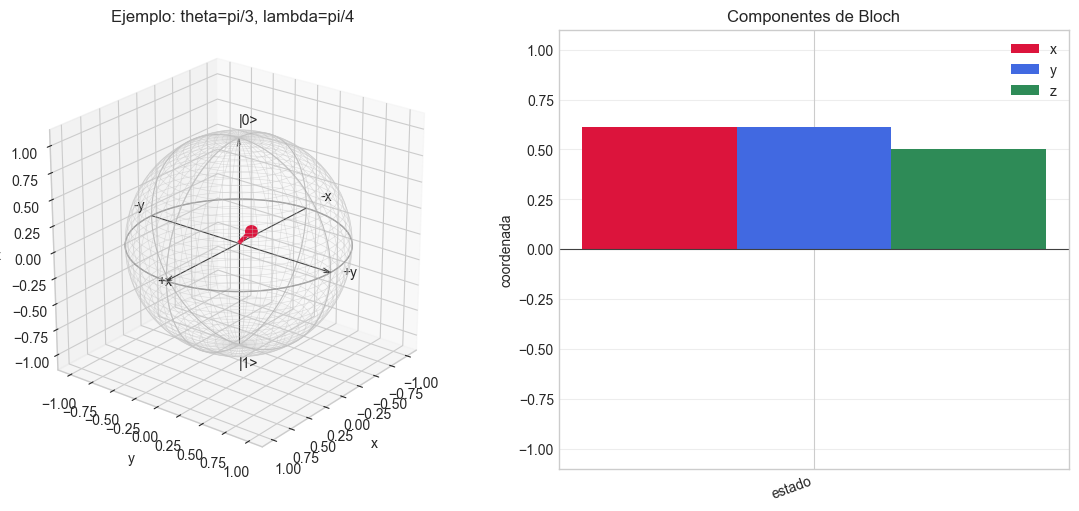


### Compuerta X aplicada a |0>

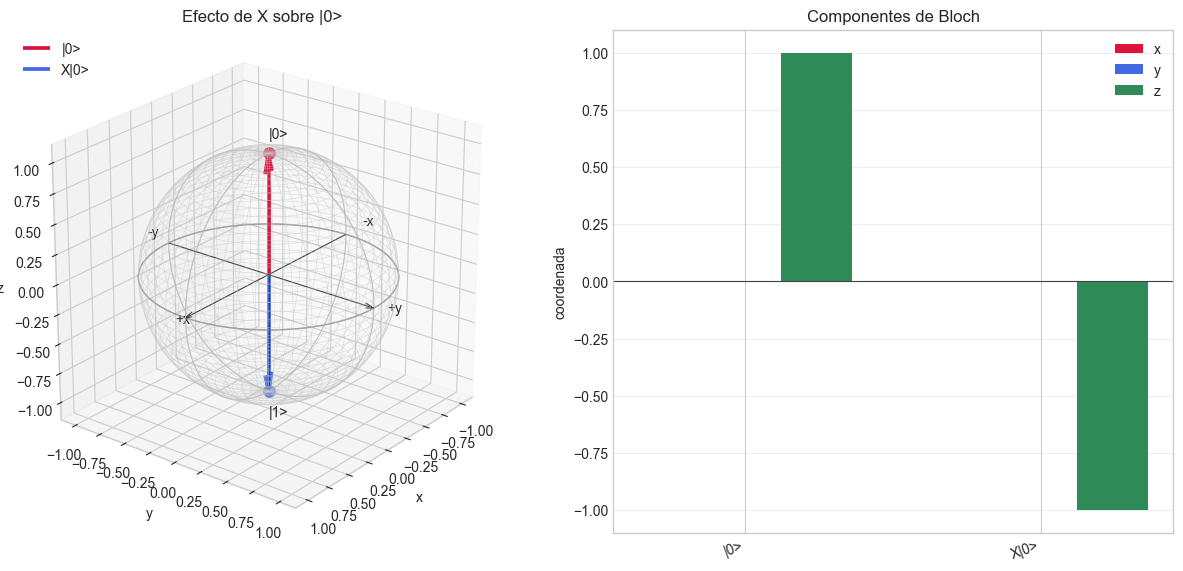


### Estados H|0> y H|1>

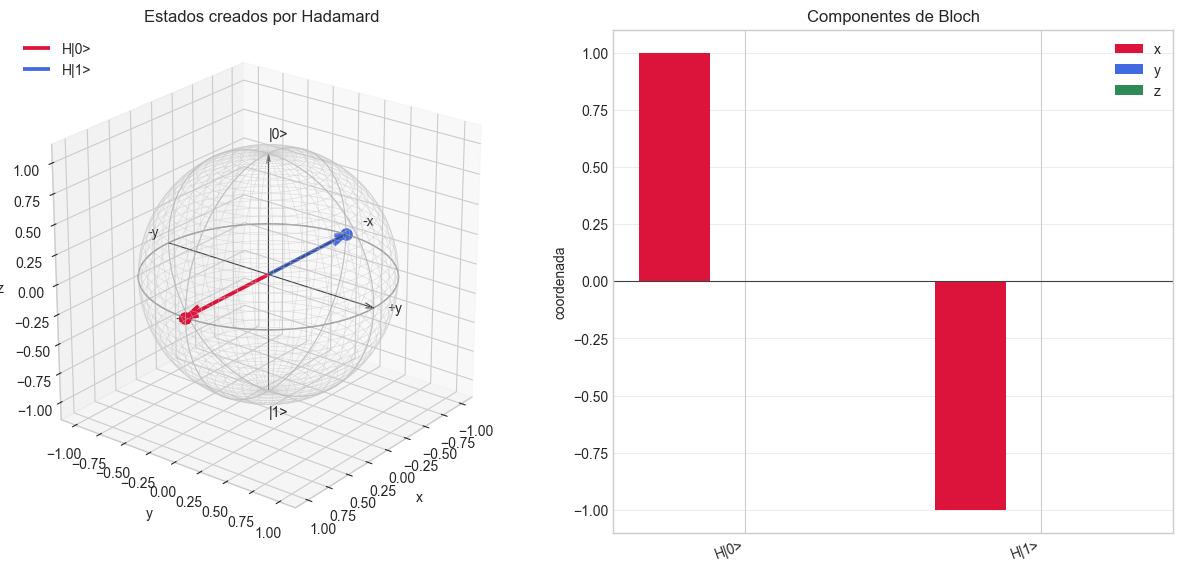


### Circuito |0> -> H -> Z

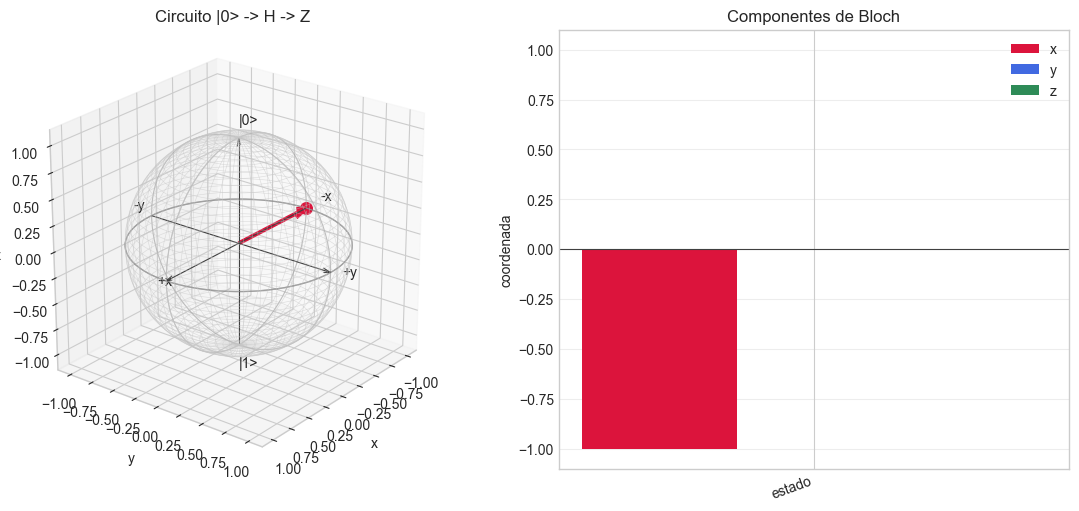


### Circuito |0> -> H -> S

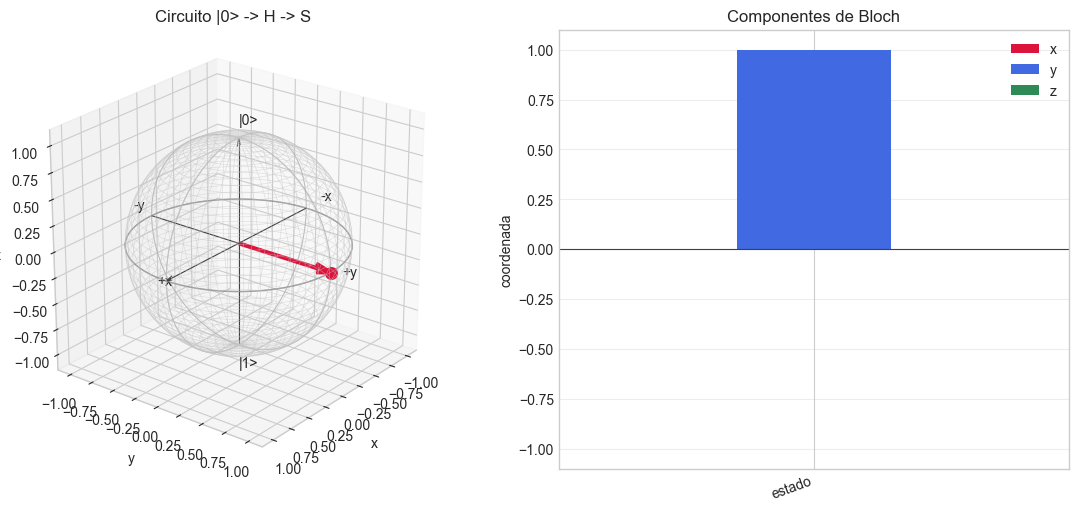


### Ejercicio integrador

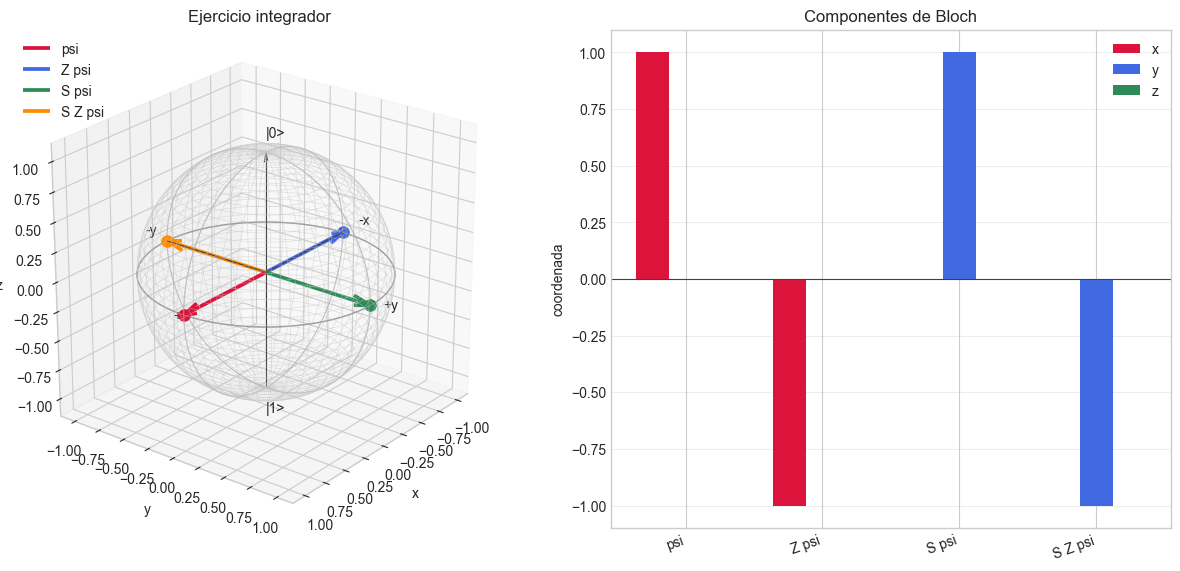


<!-- GALERIA_BLOCH_FIN -->


## 0. Preparacion del entorno

En Google Colab puede ejecutar la celda de instalacion si alguna libreria no esta disponible. En local, use Python 3.11.9 con `.venv` e instale `requirements.txt`.

In [1]:
import sys
import platform
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

print(f"Python: {sys.version.split()[0]}")
print(f"Sistema: {platform.platform()}")
print(f"Ejecutando en Colab: {IN_COLAB}")
print(f"Directorio actual: {Path.cwd()}")

Python: 3.11.9
Sistema: Windows-10-10.0.26200-SP0
Ejecutando en Colab: False
Directorio actual: D:\Proyectos\Cuantica\Labos\Labo 6


In [2]:
# En Google Colab, ejecute si falta alguna dependencia:
# %pip install -q numpy pandas matplotlib scipy sympy qiskit qiskit-aer pylatexenc

## 0.1 Librerias y utilidades

In [3]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = Path("reports")

for directory in [RAW_DIR, PROCESSED_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("[OK] Librerias base listas")

[OK] Librerias base listas


In [4]:
ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)

I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

def norm2(state):
    return float(np.real(np.vdot(state, state)))

def bloch_coordinates(state):
    alpha = complex(state[0, 0])
    beta = complex(state[1, 0])
    x = 2 * np.real(np.conjugate(alpha) * beta)
    y = 2 * np.imag(np.conjugate(alpha) * beta)
    z = abs(alpha) ** 2 - abs(beta) ** 2
    return np.array([x, y, z], dtype=float)

def print_state(label, state):
    alpha = complex(state[0, 0])
    beta = complex(state[1, 0])
    print(f"{label} =")
    print(state)
    print(f"alpha = {alpha:.4g}")
    print(f"beta  = {beta:.4g}")
    print(f"P(0)  = {abs(alpha) ** 2:.6f}")
    print(f"P(1)  = {abs(beta) ** 2:.6f}")
    print(f"norma = {norm2(state):.6f}")
    print(f"Bloch = {bloch_coordinates(state)}")

def state_from_angles(theta, lam):
    return np.array([
        [np.cos(theta / 2)],
        [np.exp(1j * lam) * np.sin(theta / 2)]
    ], dtype=complex)

def _setup_bloch_axis(ax, title):
    u = np.linspace(0, 2 * np.pi, 90)
    v = np.linspace(0, np.pi, 45)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))

    ax.plot_wireframe(xs, ys, zs, color="0.78", linewidth=0.45, alpha=0.55)
    ax.plot(np.cos(u), np.sin(u), 0 * u, color="0.45", linewidth=1.0, alpha=0.8)
    ax.plot(np.cos(u), 0 * u, np.sin(u), color="0.65", linewidth=0.8, alpha=0.7)
    ax.plot(0 * u, np.cos(u), np.sin(u), color="0.65", linewidth=0.8, alpha=0.7)

    ax.quiver(-1, 0, 0, 2, 0, 0, color="0.25", linewidth=0.8, arrow_length_ratio=0.04)
    ax.quiver(0, -1, 0, 0, 2, 0, color="0.25", linewidth=0.8, arrow_length_ratio=0.04)
    ax.quiver(0, 0, -1, 0, 0, 2, color="0.25", linewidth=0.8, arrow_length_ratio=0.04)
    ax.text(1.12, 0, 0, "+x", fontsize=10)
    ax.text(-1.22, 0, 0, "-x", fontsize=10)
    ax.text(0, 1.12, 0, "+y", fontsize=10)
    ax.text(0, -1.22, 0, "-y", fontsize=10)
    ax.text(0, 0, 1.12, "|0>", fontsize=10)
    ax.text(0, 0, -1.22, "|1>", fontsize=10)

    ax.set_xlim([-1.15, 1.15])
    ax.set_ylim([-1.15, 1.15])
    ax.set_zlim([-1.15, 1.15])
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.set_title(title)
    ax.view_init(elev=24, azim=38)
    ax.set_box_aspect((1, 1, 1))

def _plot_components(ax, vectors):
    labels = list(vectors.keys())
    coords = np.array(list(vectors.values()))
    x = np.arange(len(labels))
    width = 0.24
    ax.axhline(0, color="0.25", linewidth=0.8)
    ax.bar(x - width, coords[:, 0], width, label="x", color="crimson")
    ax.bar(x, coords[:, 1], width, label="y", color="royalblue")
    ax.bar(x + width, coords[:, 2], width, label="z", color="seagreen")
    ax.set_ylim([-1.1, 1.1])
    ax.set_ylabel("coordenada")
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_title("Componentes de Bloch")
    ax.legend(loc="upper right")
    ax.grid(True, axis="y", alpha=0.35)

def plot_bloch_vector(vector, title="Vector en la esfera de Bloch"):
    vector = np.asarray(vector, dtype=float)
    fig = plt.figure(figsize=(11, 5), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    axbar = fig.add_subplot(1, 2, 2)
    _setup_bloch_axis(ax3d, title)
    ax3d.quiver(0, 0, 0, vector[0], vector[1], vector[2], color="crimson", linewidth=3, arrow_length_ratio=0.16)
    ax3d.scatter([vector[0]], [vector[1]], [vector[2]], color="crimson", s=70, depthshade=False)
    _plot_components(axbar, {"estado": vector})
    plt.show()

def plot_bloch_vectors(states, title="Comparacion en la esfera de Bloch"):
    fig = plt.figure(figsize=(12, 5.6), constrained_layout=True)
    ax3d = fig.add_subplot(1, 2, 1, projection="3d")
    axbar = fig.add_subplot(1, 2, 2)
    _setup_bloch_axis(ax3d, title)
    colors = ["crimson", "royalblue", "seagreen", "darkorange", "purple", "teal"]
    vectors = {}
    for idx, (label, state) in enumerate(states.items()):
        vector = bloch_coordinates(state)
        vectors[label] = vector
        color = colors[idx % len(colors)]
        ax3d.quiver(0, 0, 0, vector[0], vector[1], vector[2], color=color, linewidth=2.7, arrow_length_ratio=0.16, label=label)
        ax3d.scatter([vector[0]], [vector[1]], [vector[2]], color=color, s=65, depthshade=False)
    ax3d.legend(loc="upper left")
    _plot_components(axbar, vectors)
    plt.show()

print("[OK] Estados, compuertas y funciones auxiliares listas")

[OK] Estados, compuertas y funciones auxiliares listas


# 1. Representacion del Qubit

Sea el estado:

$$
|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\lambda}\sin\frac{\theta}{2}|1\rangle
$$

La forma general de un qubit es:

$$
|\psi\rangle = \alpha |0\rangle + \beta |1\rangle
$$

Por comparacion directa:

$$
\alpha = \cos\frac{\theta}{2}
$$

$$
\beta = e^{i\lambda}\sin\frac{\theta}{2}
$$

Para verificar la normalizacion se calcula:

$$
|\alpha|^2 + |\beta|^2 = \left|\cos\frac{\theta}{2}\right|^2 + \left|e^{i\lambda}\sin\frac{\theta}{2}\right|^2
$$

Como $|e^{i\lambda}| = 1$:

$$
|\alpha|^2 + |\beta|^2 = \cos^2\frac{\theta}{2} + \sin^2\frac{\theta}{2} = 1
$$

Por lo tanto, el estado esta normalizado.

**Interpretacion fisica:** $\theta$ es el angulo polar en la esfera de Bloch y controla la distribucion de probabilidades entre $|0\rangle$ y $|1\rangle$. $\lambda$ es el angulo azimutal y representa la fase relativa entre las amplitudes de $|0\rangle$ y $|1\rangle$.

In [5]:
theta_sym, lam_sym = sp.symbols("theta lambda", real=True)
normalizacion = sp.simplify(sp.cos(theta_sym / 2) ** 2 + sp.sin(theta_sym / 2) ** 2)
normalizacion

1

# 2. Coordenadas de la Esfera de Bloch

Con:

$$
\alpha = \cos\frac{\theta}{2}, \qquad \beta = e^{i\lambda}\sin\frac{\theta}{2}
$$

Para la coordenada $z$:

$$
z = |\alpha|^2 - |\beta|^2 = \cos^2\frac{\theta}{2} - \sin^2\frac{\theta}{2}
$$

Usando la identidad $\cos^2 a - \sin^2 a = \cos(2a)$:

$$
z = \cos\theta
$$

Para $x$ y $y$ primero se calcula:

$$
\alpha^*\beta = \cos\frac{\theta}{2} e^{i\lambda}\sin\frac{\theta}{2}
$$

$$
\alpha^*\beta = \frac{1}{2}\sin\theta(\cos\lambda + i\sin\lambda)
$$

Entonces:

$$
x = 2\operatorname{Re}(\alpha^*\beta) = \sin\theta\cos\lambda
$$

$$
y = 2\operatorname{Im}(\alpha^*\beta) = \sin\theta\sin\lambda
$$

**Interpretacion fisica:** $z$ indica el desbalance de probabilidad entre medir $0$ y medir $1$. Las coordenadas $x$ e $y$ contienen informacion de coherencia y fase relativa. En conjunto, $(x,y,z)$ ubica el estado puro sobre la esfera de Bloch.

psi(theta=pi/3, lambda=pi/4) =
[[0.866 +0.j    ]
 [0.3536+0.3536j]]
alpha = 0.866+0j
beta  = 0.3536+0.3536j
P(0)  = 0.750000
P(1)  = 0.250000
norma = 1.000000
Bloch = [0.6124 0.6124 0.5   ]


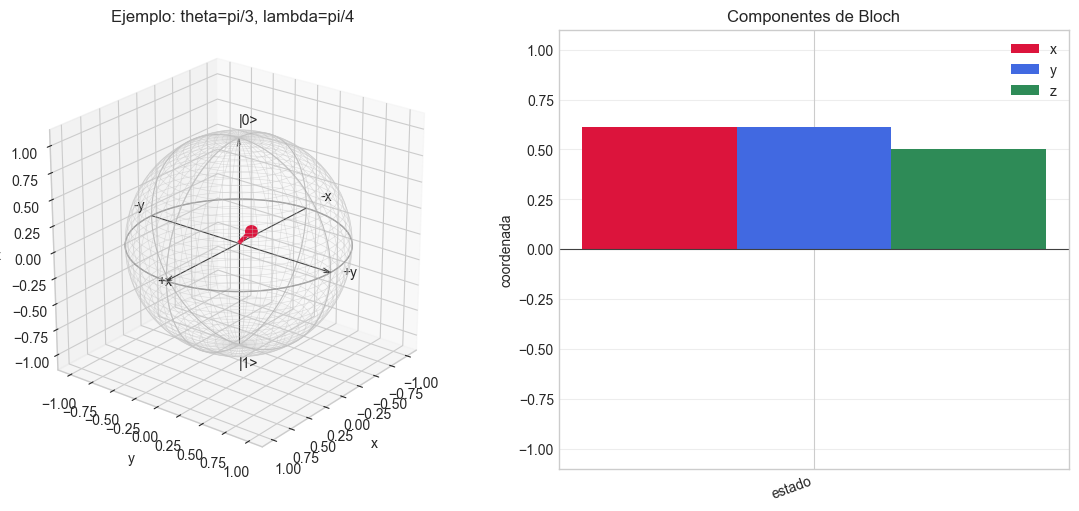

In [6]:
theta_val = np.pi / 3
lambda_val = np.pi / 4
psi_demo = state_from_angles(theta_val, lambda_val)

print_state("psi(theta=pi/3, lambda=pi/4)", psi_demo)
plot_bloch_vector(bloch_coordinates(psi_demo), "Ejemplo: theta=pi/3, lambda=pi/4")

# 3. Compuertas Cuanticas

Estados base:

$$
|0\rangle =
\begin{pmatrix}
1\\
0
\end{pmatrix},
\quad
|1\rangle =
\begin{pmatrix}
0\\
1
\end{pmatrix}
$$

## 3.1 Compuerta X

$$
X =
\begin{pmatrix}
0 & 1\\
1 & 0
\end{pmatrix}
$$

Aplicando a $|0\rangle$:

$$
X|0\rangle =
\begin{pmatrix}0 & 1\\1 & 0\end{pmatrix}
\begin{pmatrix}1\\0\end{pmatrix}
=
\begin{pmatrix}0\\1\end{pmatrix}
= |1\rangle
$$

Aplicando a $|1\rangle$:

$$
X|1\rangle =
\begin{pmatrix}0 & 1\\1 & 0\end{pmatrix}
\begin{pmatrix}0\\1\end{pmatrix}
=
\begin{pmatrix}1\\0\end{pmatrix}
= |0\rangle
$$

**Interpretacion:** la compuerta $X$ es un cambio de bit cuantico. Intercambia $|0\rangle$ y $|1\rangle$. En la esfera de Bloch equivale a una rotacion de $\pi$ alrededor del eje $x$.

X|0> =
[[0.+0.j]
 [1.+0.j]]
alpha = 0+0j
beta  = 1+0j
P(0)  = 0.000000
P(1)  = 1.000000
norma = 1.000000
Bloch = [ 0.  0. -1.]

X|1> =
[[1.+0.j]
 [0.+0.j]]
alpha = 1+0j
beta  = 0+0j
P(0)  = 1.000000
P(1)  = 0.000000
norma = 1.000000
Bloch = [0. 0. 1.]


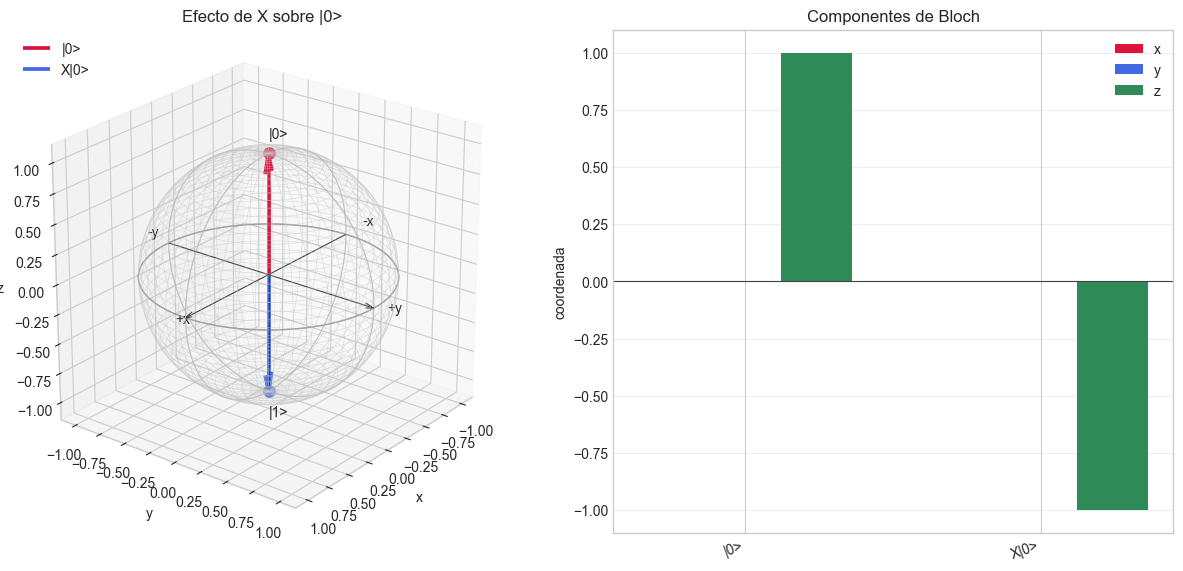

In [7]:
resultado_X0 = X @ ket0
resultado_X1 = X @ ket1
print_state("X|0>", resultado_X0)
print()
print_state("X|1>", resultado_X1)
plot_bloch_vectors({"|0>": ket0, "X|0>": resultado_X0}, "Efecto de X sobre |0>")

## 3.2 Compuerta Z

$$
Z =
\begin{pmatrix}
1 & 0\\
0 & -1
\end{pmatrix}
$$

Aplicando a $|0\rangle$:

$$
Z|0\rangle =
\begin{pmatrix}1 & 0\\0 & -1\end{pmatrix}
\begin{pmatrix}1\\0\end{pmatrix}
=
\begin{pmatrix}1\\0\end{pmatrix}
= |0\rangle
$$

Aplicando a $|1\rangle$:

$$
Z|1\rangle =
\begin{pmatrix}1 & 0\\0 & -1\end{pmatrix}
\begin{pmatrix}0\\1\end{pmatrix}
=
\begin{pmatrix}0\\-1\end{pmatrix}
= -|1\rangle
$$

**Efecto de fase:** $Z$ no cambia las probabilidades de los estados base, pero cambia el signo de la amplitud de $|1\rangle$. En superposiciones, esto introduce una fase relativa de $\pi$.

In [8]:
resultado_Z0 = Z @ ket0
resultado_Z1 = Z @ ket1
print_state("Z|0>", resultado_Z0)
print()
print_state("Z|1>", resultado_Z1)

Z|0> =
[[1.+0.j]
 [0.+0.j]]
alpha = 1+0j
beta  = 0+0j
P(0)  = 1.000000
P(1)  = 0.000000
norma = 1.000000
Bloch = [0. 0. 1.]

Z|1> =
[[ 0.+0.j]
 [-1.+0.j]]
alpha = 0+0j
beta  = -1+0j
P(0)  = 0.000000
P(1)  = 1.000000
norma = 1.000000
Bloch = [ 0.  0. -1.]


## 3.3 Compuerta S

$$
S =
\begin{pmatrix}
1 & 0\\
0 & i
\end{pmatrix}
$$

Aplicando a $|0\rangle$:

$$
S|0\rangle = |0\rangle
$$

Aplicando a $|1\rangle$:

$$
S|1\rangle = i|1\rangle
$$

Por la formula de Euler:

$$
e^{i\phi} = \cos\phi + i\sin\phi
$$

Si $\phi = \pi/2$:

$$
e^{i\pi/2} = \cos\frac{\pi}{2} + i\sin\frac{\pi}{2} = 0 + i = i
$$

**Interpretacion:** $S$ agrega una fase relativa de $\pi/2$ a la componente $|1\rangle$.

In [9]:
resultado_S0 = S @ ket0
resultado_S1 = S @ ket1
print_state("S|0>", resultado_S0)
print()
print_state("S|1>", resultado_S1)
print()
print("exp(i*pi/2) =", np.exp(1j * np.pi / 2))

S|0> =
[[1.+0.j]
 [0.+0.j]]
alpha = 1+0j
beta  = 0+0j
P(0)  = 1.000000
P(1)  = 0.000000
norma = 1.000000
Bloch = [0. 0. 1.]

S|1> =
[[0.+0.j]
 [0.+1.j]]
alpha = 0+0j
beta  = 0+1j
P(0)  = 0.000000
P(1)  = 1.000000
norma = 1.000000
Bloch = [ 0.  0. -1.]

exp(i*pi/2) = (6.123233995736766e-17+1j)


# 4. Compuerta Hadamard

Sea:

$$
H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1\\
1 & -1
\end{pmatrix}
$$

Aplicando a $|0\rangle$:

$$
H|0\rangle = \frac{1}{\sqrt{2}}
\begin{pmatrix}1 & 1\\1 & -1\end{pmatrix}
\begin{pmatrix}1\\0\end{pmatrix}
= \frac{1}{\sqrt{2}}
\begin{pmatrix}1\\1\end{pmatrix}
= \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Aplicando a $|1\rangle$:

$$
H|1\rangle = \frac{1}{\sqrt{2}}
\begin{pmatrix}1 & 1\\1 & -1\end{pmatrix}
\begin{pmatrix}0\\1\end{pmatrix}
= \frac{1}{\sqrt{2}}
\begin{pmatrix}1\\-1\end{pmatrix}
= \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

**Interpretacion:** Hadamard transforma los estados base en superposiciones con probabilidades iguales de medir $0$ o $1$. La diferencia entre ambos resultados esta en la fase relativa.

H|0> =
[[0.7071+0.j]
 [0.7071+0.j]]
alpha = 0.7071+0j
beta  = 0.7071+0j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [1. 0. 0.]

H|1> =
[[ 0.7071+0.j]
 [-0.7071+0.j]]
alpha = 0.7071+0j
beta  = -0.7071+0j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [-1.  0.  0.]


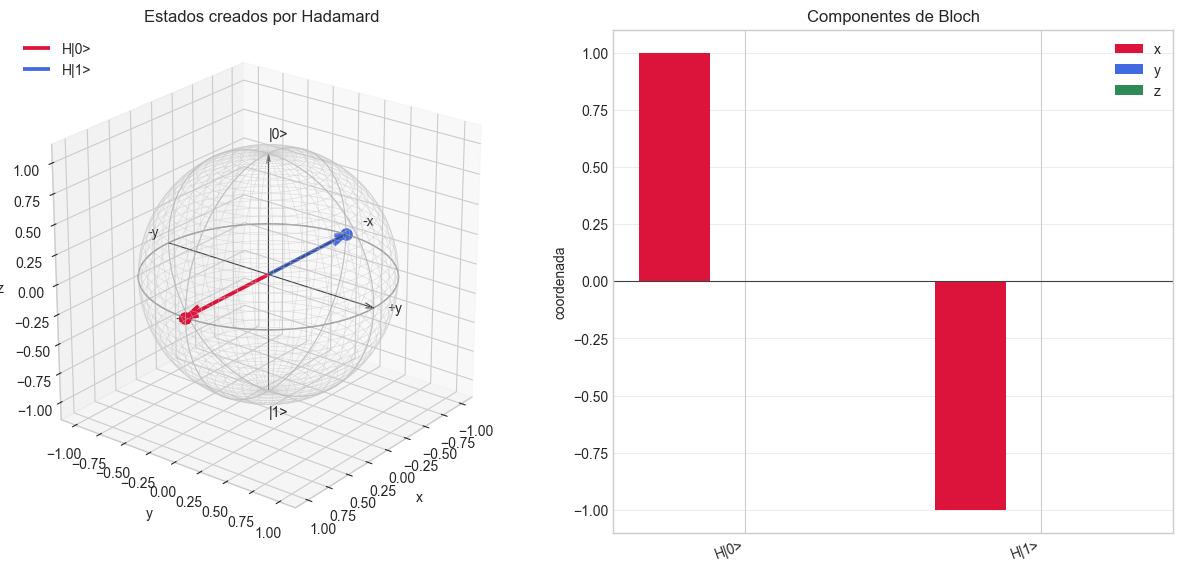

In [10]:
resultado_H0 = H @ ket0
resultado_H1 = H @ ket1
print_state("H|0>", resultado_H0)
print()
print_state("H|1>", resultado_H1)
plot_bloch_vectors({"H|0>": resultado_H0, "H|1>": resultado_H1}, "Estados creados por Hadamard")

# 5. Circuitos Cuanticos

En los circuitos se aplican las compuertas de izquierda a derecha sobre el ket. Matricialmente, la ultima compuerta escrita en el circuito queda a la izquierda del producto.

## 5.1 Circuito $|0\rangle \rightarrow H \rightarrow Z$

Primero:

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Luego se aplica $Z$:

$$
ZH|0\rangle = Z\frac{|0\rangle + |1\rangle}{\sqrt{2}}
= \frac{Z|0\rangle + Z|1\rangle}{\sqrt{2}}
= \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

**Interpretacion:** el circuito genera el estado $| - \rangle$. Las probabilidades siguen siendo $1/2$ y $1/2$, pero la fase relativa cambia de $0$ a $\pi$. En la esfera de Bloch, el vector queda sobre el eje $x$ negativo.

Z H |0> =
[[ 0.7071+0.j]
 [-0.7071+0.j]]
alpha = 0.7071+0j
beta  = -0.7071+0j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [-1.  0.  0.]


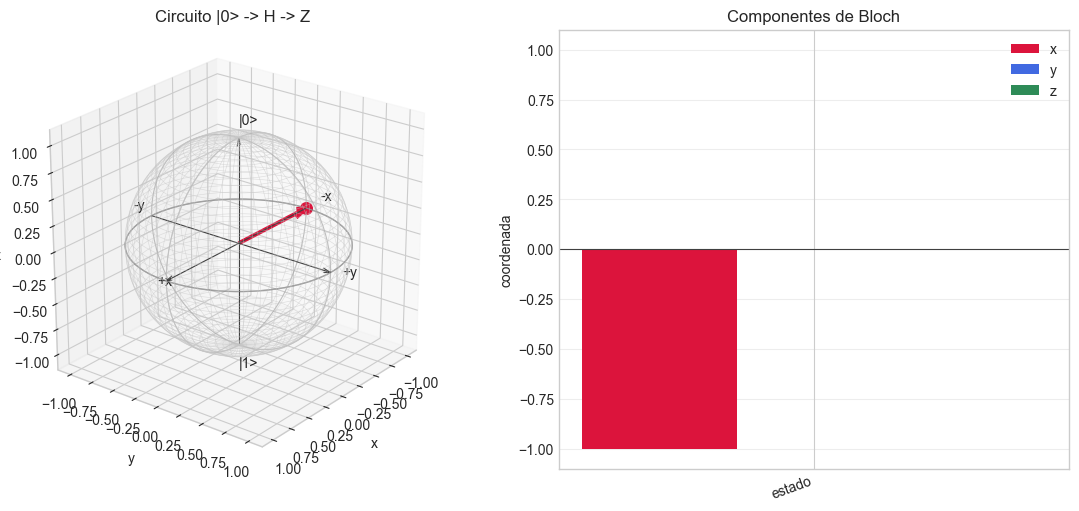

In [11]:
estado_HZ = Z @ H @ ket0
print_state("Z H |0>", estado_HZ)
plot_bloch_vector(bloch_coordinates(estado_HZ), "Circuito |0> -> H -> Z")

## 5.2 Circuito $|0\rangle \rightarrow H \rightarrow S$

Primero:

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}
$$

Luego se aplica $S$:

$$
SH|0\rangle = S\frac{|0\rangle + |1\rangle}{\sqrt{2}}
= \frac{S|0\rangle + S|1\rangle}{\sqrt{2}}
= \frac{|0\rangle + i|1\rangle}{\sqrt{2}}
$$

**Interpretacion:** el circuito introduce una fase relativa de $\pi/2$ en la componente $|1\rangle$. Las probabilidades de medir $0$ y $1$ no cambian, pero el punto se mueve desde el eje $x$ positivo al eje $y$ positivo en la esfera de Bloch.

S H |0> =
[[0.7071+0.j    ]
 [0.    +0.7071j]]
alpha = 0.7071+0j
beta  = 0+0.7071j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [0. 1. 0.]


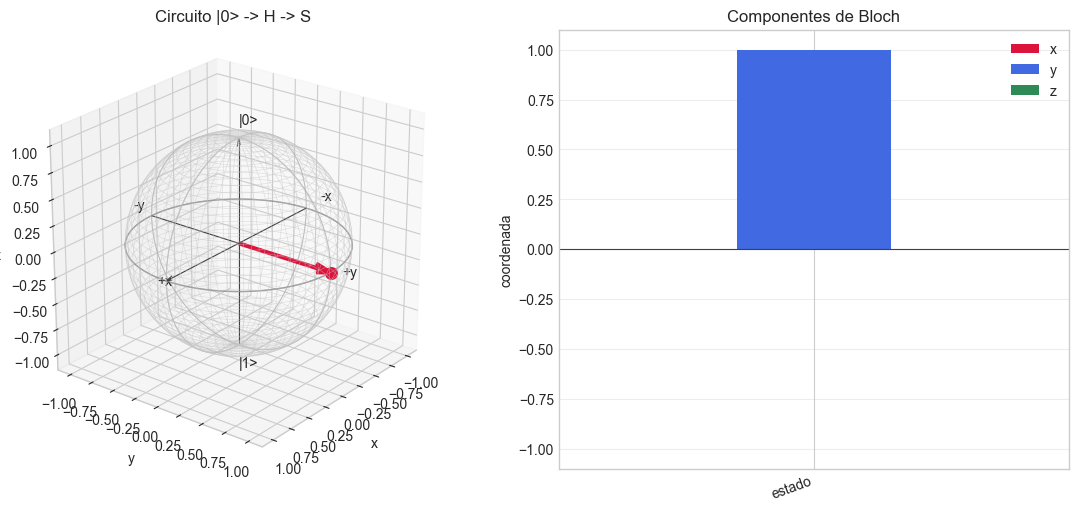

In [12]:
estado_HS = S @ H @ ket0
print_state("S H |0>", estado_HS)
plot_bloch_vector(bloch_coordinates(estado_HS), "Circuito |0> -> H -> S")

# 6. Demostraciones Importantes

## 6.1 Demostracion de $S^2 = Z$

$$
S^2 =
\begin{pmatrix}1 & 0\\0 & i\end{pmatrix}
\begin{pmatrix}1 & 0\\0 & i\end{pmatrix}
=
\begin{pmatrix}1 & 0\\0 & i^2\end{pmatrix}
=
\begin{pmatrix}1 & 0\\0 & -1\end{pmatrix}
= Z
$$

## 6.2 La fase global no afecta probabilidades

Sea:

$$
|\psi\rangle = \alpha|0\rangle + \beta|1\rangle
$$

Si se multiplica por una fase global:

$$
e^{i\gamma}|\psi\rangle = e^{i\gamma}\alpha|0\rangle + e^{i\gamma}\beta|1\rangle
$$

Las probabilidades son:

$$
|e^{i\gamma}\alpha|^2 = |e^{i\gamma}|^2|\alpha|^2 = |\alpha|^2
$$

$$
|e^{i\gamma}\beta|^2 = |e^{i\gamma}|^2|\beta|^2 = |\beta|^2
$$

Como $|e^{i\gamma}| = 1$, la fase global no cambia probabilidades.

## 6.3 Fase global y fase relativa

Una fase global multiplica todo el estado por el mismo factor complejo y no tiene efecto observable directo. Una fase relativa cambia la fase entre componentes, por ejemplo entre $|0\rangle$ y $|1\rangle$, y si puede afectar interferencia, coordenadas de Bloch y resultados despues de aplicar otras compuertas.

In [13]:
S_cuadrado = S @ S
print("S^2 =")
print(S_cuadrado)
print("S^2 coincide con Z:", np.allclose(S_cuadrado, Z))

gamma = np.pi / 5
psi = state_from_angles(np.pi / 3, np.pi / 7)
psi_global = np.exp(1j * gamma) * psi

print("\nProbabilidades originales:", np.abs(psi.flatten()) ** 2)
print("Probabilidades con fase global:", np.abs(psi_global.flatten()) ** 2)
print("Mismas probabilidades:", np.allclose(np.abs(psi.flatten()) ** 2, np.abs(psi_global.flatten()) ** 2))

S^2 =
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
S^2 coincide con Z: True

Probabilidades originales: [0.75 0.25]
Probabilidades con fase global: [0.75 0.25]
Mismas probabilidades: True


# 7. Ejercicio Integrador

Sea:

$$
|\psi\rangle = \frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)
$$

Este es el estado $|+\rangle$, con amplitudes:

$$
\alpha = \frac{1}{\sqrt{2}}, \qquad \beta = \frac{1}{\sqrt{2}}
$$

Sus coordenadas son:

$$
x = 2\operatorname{Re}(\alpha^*\beta) = 1, \qquad y = 0, \qquad z = 0
$$

Por tanto, el estado inicial esta sobre el eje $x$ positivo.

## Aplicando $Z$

$$
Z|\psi\rangle = Z\frac{|0\rangle + |1\rangle}{\sqrt{2}}
= \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

Este estado tiene coordenadas:

$$
(x,y,z)=(-1,0,0)
$$

## Aplicando $S$

Aplicando $S$ al estado inicial:

$$
S|\psi\rangle = S\frac{|0\rangle + |1\rangle}{\sqrt{2}}
= \frac{|0\rangle + i|1\rangle}{\sqrt{2}}
$$

Sus coordenadas son:

$$
(x,y,z)=(0,1,0)
$$

**Interpretacion:** $Z$ rota el estado desde $+x$ hacia $-x$, introduciendo una fase relativa de $\pi$. $S$ rota el estado desde $+x$ hacia $+y$, introduciendo una fase relativa de $\pi/2$. En ambos casos las probabilidades de medir $0$ y $1$ son iguales, pero cambia la fase relativa y por eso cambia la posicion en la esfera de Bloch.

Si se interpretara como aplicacion secuencial $|\psi\rangle \rightarrow Z \rightarrow S$, el resultado seria:

$$
SZ|\psi\rangle = \frac{|0\rangle - i|1\rangle}{\sqrt{2}}
$$

con coordenadas $(0,-1,0)$.

psi =
[[0.7071+0.j]
 [0.7071+0.j]]
alpha = 0.7071+0j
beta  = 0.7071+0j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [1. 0. 0.]

Z psi =
[[ 0.7071+0.j]
 [-0.7071+0.j]]
alpha = 0.7071+0j
beta  = -0.7071+0j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [-1.  0.  0.]

S psi =
[[0.7071+0.j    ]
 [0.    +0.7071j]]
alpha = 0.7071+0j
beta  = 0+0.7071j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [0. 1. 0.]

S Z psi =
[[0.7071+0.j    ]
 [0.    -0.7071j]]
alpha = 0.7071+0j
beta  = 0-0.7071j
P(0)  = 0.500000
P(1)  = 0.500000
norma = 1.000000
Bloch = [ 0. -1.  0.]


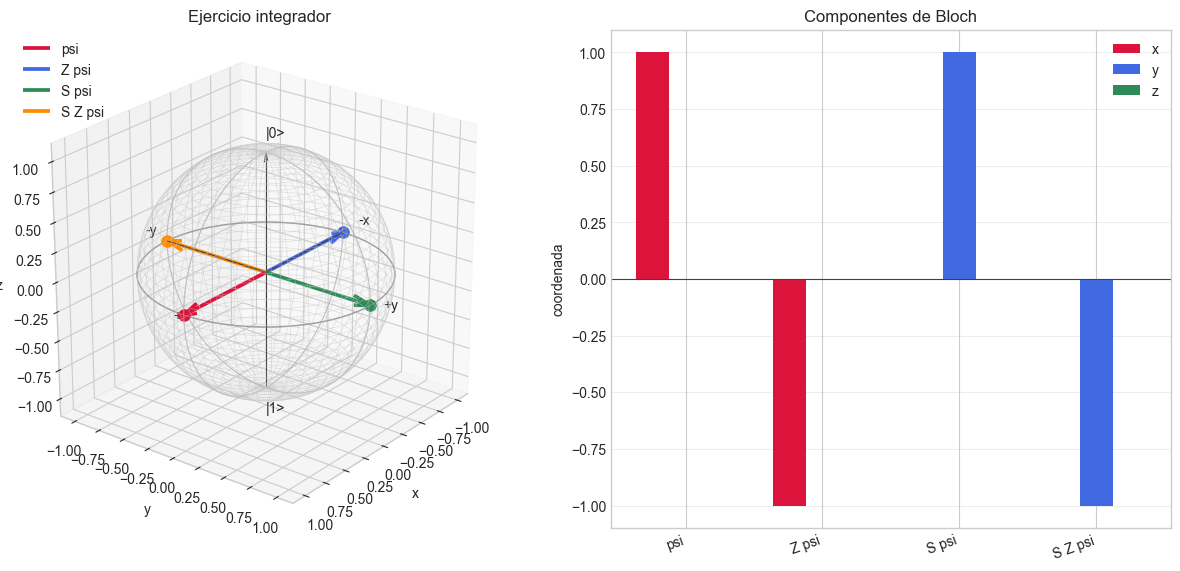

In [14]:
psi = (1 / np.sqrt(2)) * (ket0 + ket1)
psi_Z = Z @ psi
psi_S = S @ psi
psi_ZS = S @ Z @ psi

print_state("psi", psi)
print()
print_state("Z psi", psi_Z)
print()
print_state("S psi", psi_S)
print()
print_state("S Z psi", psi_ZS)

plot_bloch_vectors({
    "psi": psi,
    "Z psi": psi_Z,
    "S psi": psi_S,
    "S Z psi": psi_ZS,
}, "Ejercicio integrador")

# 8. Nivel Computacional Opcional

A continuacion se implementan los circuitos en Qiskit para comparar con los resultados teoricos. Si Qiskit no esta instalado, ejecute la celda de instalacion del inicio.

In [15]:
try:
    import qiskit
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector
    from qiskit.visualization import plot_bloch_multivector
    print(f"[OK] Qiskit disponible: {qiskit.__version__}")
except Exception as exc:
    print("[WARN] Qiskit no esta disponible. Instale las dependencias y vuelva a ejecutar.")
    print(f"Detalle: {exc}")

[OK] Qiskit disponible: 2.4.1


Circuito H -> Z


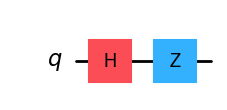

Statevector([ 0.7071+0.j, -0.7071+0.j],
            dims=(2,))


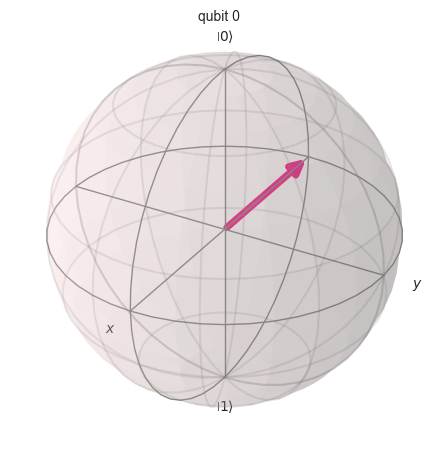

In [16]:
# Circuito |0> -> H -> Z
try:
    qc_hz = QuantumCircuit(1)
    qc_hz.h(0)
    qc_hz.z(0)
    estado_qiskit_hz = Statevector.from_instruction(qc_hz)
    print("Circuito H -> Z")
    display(qc_hz.draw("mpl"))
    print(estado_qiskit_hz)
    display(plot_bloch_multivector(estado_qiskit_hz))
except NameError:
    print("Qiskit no esta cargado.")

Circuito H -> S


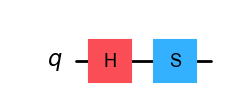

Statevector([0.7071+0.j    , 0.    +0.7071j],
            dims=(2,))


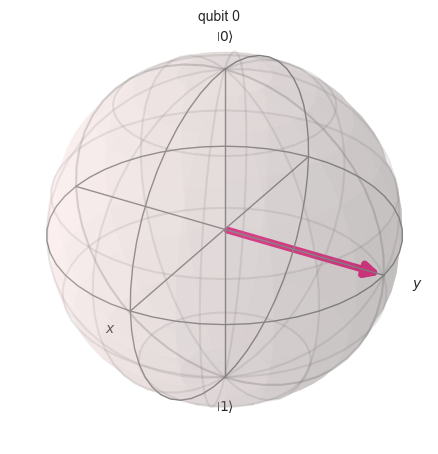

In [17]:
# Circuito |0> -> H -> S
try:
    qc_hs = QuantumCircuit(1)
    qc_hs.h(0)
    qc_hs.s(0)
    estado_qiskit_hs = Statevector.from_instruction(qc_hs)
    print("Circuito H -> S")
    display(qc_hs.draw("mpl"))
    print(estado_qiskit_hs)
    display(plot_bloch_multivector(estado_qiskit_hs))
except NameError:
    print("Qiskit no esta cargado.")

# Conclusiones

- Un qubit puro puede representarse mediante dos angulos: $\theta$ controla las probabilidades y $\lambda$ controla la fase relativa.
- Las coordenadas de Bloch permiten visualizar amplitudes, probabilidades y fase relativa en un vector tridimensional.
- Las compuertas $X$, $Z$, $S$ y $H$ modifican el estado mediante rotaciones o cambios de fase.
- La fase global no cambia resultados de medicion, pero la fase relativa si tiene efectos fisicos observables por interferencia.
- Los graficos y la simulacion en Qiskit coinciden con los resultados teoricos obtenidos por algebra matricial.